# 📦 Batch Machine Learning (Offline Learning)

> *A training approach where the model is trained on the entire dataset at once — like a student reading the whole semester's notes together and sitting one final exam, instead of studying a little every day.*

## 🎯 In One Line

**Batch Learning** (also called **Offline Learning**) is a training approach where the model is trained on the **entire dataset at once**. Once training finishes, the model is deployed — and it does **not** learn continuously from new data. Instead, it must be **fully retrained on a schedule** (e.g., nightly, weekly, monthly) using the whole updated dataset.

> 💡 **Simple analogy:** It's like a student who studies the entire semester's syllabus at once and takes one exam — they don't update their knowledge daily. When the next semester starts, they must sit down and study the whole (now larger) syllabus again from scratch.

## ⚙️ How It Works

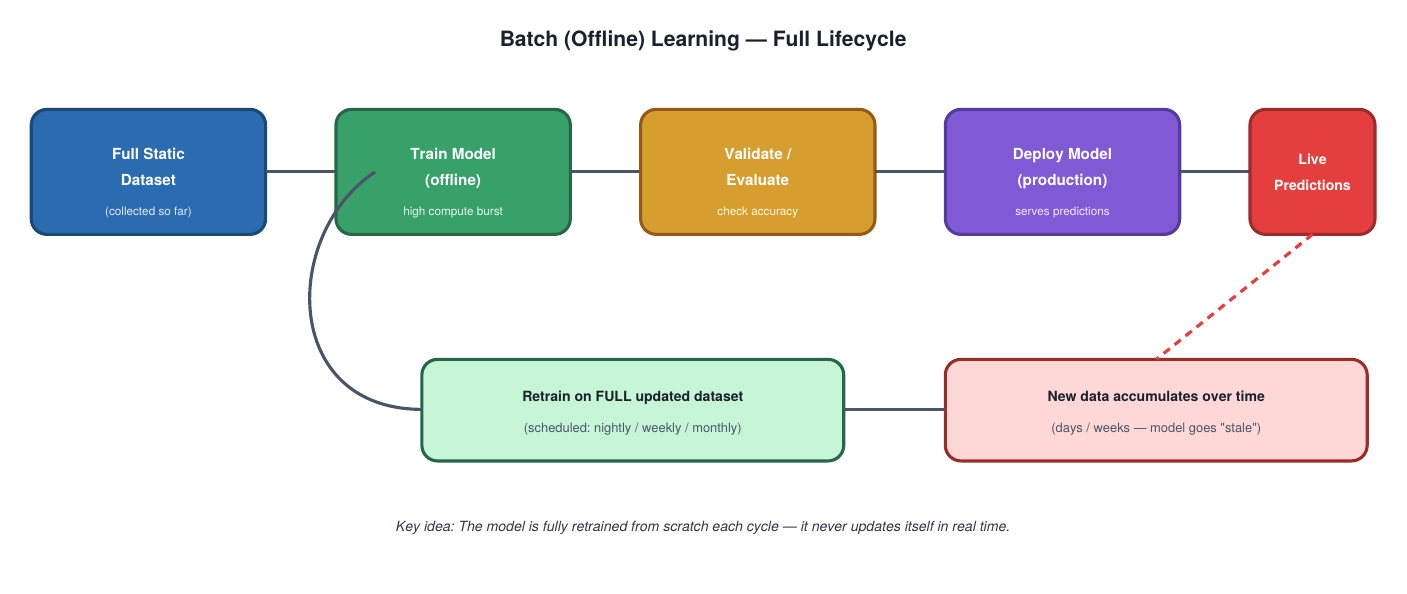

| Step | What Happens |
|---|---|
| ① **Collect Static Data** | The complete dataset gathered so far is prepared |
| ② **Model Training** | The model is trained on the whole dataset at once (offline, high compute) |
| ③ **Validation** | Accuracy, precision, and recall are checked on a test/validation set |
| ④ **Deployment** | The trained model is released into production |
| ⑤ **Serving** | The model serves live predictions, but does not learn on its own |
| ⑥ **Data Accumulation** | New data piles up over time — the model gradually becomes **stale** |
| ⑦ **Scheduled Retraining** | On a fixed schedule (daily/weekly/monthly), the model is **retrained from scratch** on the full updated dataset |

## 🧬 Characteristics

| Characteristic | Explanation |
|---|---|
| 🗂️ **Static Nature** | The dataset is fixed at training time — not directly suited to real-time/streaming data |
| 🔁 **Periodic Training** | When new data arrives, the model is retrained **from scratch** on old + new data combined |
| 🖥️ **High Computational Cost** | Large datasets mean training takes significant time and resources (GPU/CPU, RAM) |
| 📉 **Model Drift Risk** | If the real world changes between training runs, accuracy can degrade — this is called **Concept Drift** |

## ⚖️ Batch Learning vs Online Learning

> This is the most important distinction — Batch Learning only really makes sense when contrasted with its counterpart, **Online (Incremental) Learning**.

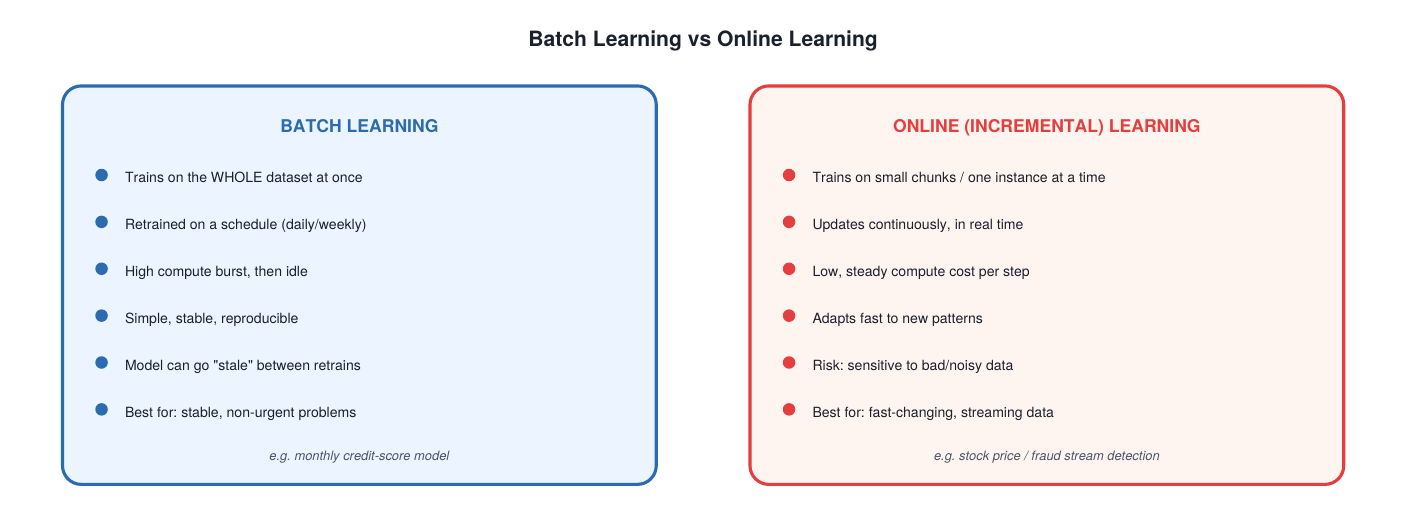

| Feature | 📦 Batch Learning | ⚡ Online Learning |
|---|---|---|
| Training data | Entire dataset at once | Small chunks / one instance at a time |
| Update frequency | Scheduled (periodic) | Continuous, real-time |
| Compute pattern | Sudden heavy load, then idle | Always light, steady load |
| Adapting to change | Slow — stays outdated until retrained | Fast — learns new patterns immediately |
| Stability | More stable, reproducible | Can learn from noisy data incorrectly |
| Best suited for | Slowly-changing problems | Fast-changing / streaming problems |
| Example | Monthly credit-scoring model | Stock price or live fraud detection |

> ⚠️ **Careful:** Don't confuse the word "batch" here with **Mini-batch Gradient Descent**. That's an **internal training algorithm technique** (how many samples are used per weight-update step), while Batch Learning is a **system-level strategy** (when and how the model learns overall).

## ✅ Advantages

| # | Advantage |
|---|---|
| 1 | **Simple to Implement** — easy to use once trained |
| 2 | **Effective for Large, Stable Datasets** — works well on large historical data |
| 3 | **Reproducible & Stable** — training on the same data gives nearly the same result each time |
| 4 | **Easier Debugging** — the whole pipeline can be tested in a controlled environment |

## ❌ Disadvantages

| # | Disadvantage |
|---|---|
| 1 | **Not Suitable for Real-Time Data** — doesn't fit live/streaming data well |
| 2 | **Time-Consuming** — retraining on the full dataset each time takes time and resources |
| 3 | **Overfitting Risk** — over-reliance on static data can hurt performance on new patterns |
| 4 | **Model Staleness** — the model can't capture real-world changes between retraining cycles |

## 🌍 Real-World Examples

| Domain | Use Case |
|---|---|
| 🏦 **Fraud Detection** | Detecting fraud based on bank transaction data (periodic retrain) |
| 📉 **Customer Churn Prediction** | Predicting which customers might cancel a service, based on customer data |
| 🌦️ **Weather Prediction Models** | Models retrained periodically using historical weather data |
| 🛒 **Recommendation Systems** | Systems like Netflix/Amazon retrain nightly on the full user-activity dataset |
| 💳 **Credit Scoring** | Scoring models retrained monthly on the complete set of borrower data |

## 🐍 Python Example — A Realistic Batch Retraining Pipeline

The code below doesn't just do a single train/test split — it **simulates a real batch learning system**, showing how a model is periodically retrained as new data accumulates over time.

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

# ------------------------------------------------------------------
# 1. Create a large, realistic dataset (as an example)
# ------------------------------------------------------------------
X, y = make_classification(
    n_samples=5000, n_features=10, n_informative=6,
    n_redundant=2, random_state=42
)

# Suppose data arrives in 5 "batches" (5 months)
n_batches = 5
batch_size = len(X) // n_batches
batches = [
    (X[i * batch_size:(i + 1) * batch_size],
     y[i * batch_size:(i + 1) * batch_size])
    for i in range(n_batches)
]

# ------------------------------------------------------------------
# 2. Batch Learning simulation — each month, the model is retrained
#    from scratch on the full accumulated dataset
# ------------------------------------------------------------------
accumulated_X, accumulated_y = np.empty((0, X.shape[1])), np.empty((0,))
model = None
history = []

for month, (batch_X, batch_y) in enumerate(batches, start=1):
    # The new batch is appended to the accumulated data
    accumulated_X = np.vstack([accumulated_X, batch_X])
    accumulated_y = np.concatenate([accumulated_y, batch_y])

    # Train/test split on the full accumulated dataset
    X_train, X_test, y_train, y_test = train_test_split(
        accumulated_X, accumulated_y, test_size=0.2, random_state=42
    )

    # A brand-new model is trained each cycle (the core idea of Batch Learning)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Evaluation
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    history.append(acc)

    print(f"Month {month}: "
          f"total samples used = {len(accumulated_X):>4} | "
          f"accuracy = {acc:.4f}")

# ------------------------------------------------------------------
# 3. Save the final model for production
# ------------------------------------------------------------------
joblib.dump(model, "batch_model_latest.pkl")
print("\nFinal retrained model saved as 'batch_model_latest.pkl'")
print(f"Accuracy trend over months: {[round(a, 3) for a in history]}")

Month 1: total samples used = 1000 | accuracy = 0.8850
Month 2: total samples used = 2000 | accuracy = 0.8575
Month 3: total samples used = 3000 | accuracy = 0.9033
Month 4: total samples used = 4000 | accuracy = 0.8962
Month 5: total samples used = 5000 | accuracy = 0.9210

Final retrained model saved as 'batch_model_latest.pkl'
Accuracy trend over months: [0.885, 0.858, 0.903, 0.896, 0.921]


### 🔍 Code Explanation

| Step | What's Happening |
|---|---|
| **Data generation** | `make_classification` creates a realistic synthetic dataset |
| **Batch simulation** | The dataset is split into 5 parts to simulate new data arriving each month |
| **Accumulation** | Each month's new batch is appended to all previous data (Batch Learning never discards old data) |
| **From-scratch retrain** | A **brand-new `RandomForestClassifier`** is trained on the full accumulated dataset every month — this is the core idea of batch learning |
| **Model persistence** | The final model is saved with `joblib`, ready to be deployed to production |

> 🧠 **Notice:** Every month, the model is built completely from scratch (`RandomForestClassifier(...)` is called again) — this is what separates Batch Learning from Online Learning, where the model would instead be **incrementally updated** with new data rather than rebuilt from zero.

## 🧠 Quick Revision Questions

1. When does a Batch Learning model actually learn from new data?
2. What's the difference between the "batch" in Batch Learning and the "batch" in Mini-batch Gradient Descent?
3. What is Concept Drift, and why is it risky for Batch Learning?
4. In what kind of problems does Online Learning outperform Batch Learning?
5. Give three real-world examples where Batch Learning is used.